<a href="https://colab.research.google.com/github/sl007ha/qqq-risk-monitor/blob/main/notebooks/04_pmi_substitute.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install fredapi --quiet

In [4]:
from fredapi import Fred
from google.colab import userdata
import pandas as pd

fred = Fred(api_key=userdata.get('FRED_API_KEY'))

# CFNAI = 综合经济活动指数；正值 = 高于趋势，负值 = 低于趋势
# CFNAIMA3 = 3 个月移动平均，更稳定，是芝加哥联储官方推荐使用的版本
cfnai_ma3 = fred.get_series('CFNAIMA3', observation_start='1967-01-01')
cfnai_ma3 = cfnai_ma3.resample('ME').last()
cfnai_ma3 = cfnai_ma3.to_frame('cfnai_ma3')
print(cfnai_ma3.tail())

# 也拉一下纯 CFNAI（不平滑），作为辅助
cfnai = fred.get_series('CFNAI', observation_start='1967-01-01')
cfnai = cfnai.resample('ME').last()
cfnai_ma3['cfnai'] = cfnai

print(cfnai_ma3.tail(12))

            cfnai_ma3
2025-11-30      -0.36
2025-12-31      -0.26
2026-01-31      -0.07
2026-02-28       0.03
2026-03-31      -0.03
            cfnai_ma3  cfnai
2025-04-30       0.06  -0.37
2025-05-31      -0.17  -0.29
2025-06-30      -0.24  -0.07
2025-07-31      -0.12   0.01
2025-08-31      -0.14  -0.36
2025-09-30      -0.22  -0.31
2025-10-31      -0.39  -0.49
2025-11-30      -0.36  -0.27
2025-12-31      -0.26  -0.02
2026-01-31      -0.07   0.08
2026-02-28       0.03   0.03
2026-03-31      -0.03  -0.20


In [5]:
# 看几个关键时刻
print("2007–2009 GFC:")
print(cfnai_ma3.loc['2007-01':'2009-12'])

print("\n2000 dot-com:")
print(cfnai_ma3.loc['2000-01':'2001-12'])

2007–2009 GFC:
            cfnai_ma3  cfnai
2007-01-31       0.06  -0.48
2007-02-28       0.16   0.20
2007-03-31      -0.01   0.24
2007-04-30       0.11  -0.09
2007-05-31       0.07   0.05
2007-06-30      -0.02  -0.02
2007-07-31      -0.12  -0.40
2007-08-31      -0.16  -0.07
2007-09-30      -0.18  -0.08
2007-10-31      -0.14  -0.27
2007-11-30      -0.14  -0.08
2007-12-31      -0.26  -0.44
2008-01-31      -0.25  -0.23
2008-02-29      -0.49  -0.79
2008-03-31      -0.60  -0.79
2008-04-30      -0.75  -0.67
2008-05-31      -0.76  -0.84
2008-06-30      -0.74  -0.71
2008-07-31      -0.92  -1.21
2008-08-31      -1.06  -1.25
2008-09-30      -1.68  -2.58
2008-10-31      -1.65  -1.13
2008-11-30      -2.02  -2.34
2008-12-31      -2.05  -2.67
2009-01-31      -2.68  -3.04
2009-02-28      -2.32  -1.24
2009-03-31      -2.21  -2.34
2009-04-30      -1.73  -1.61
2009-05-31      -1.71  -1.19
2009-06-30      -1.24  -0.93
2009-07-31      -0.66   0.14
2009-08-31      -0.27   0.00
2009-09-30      -0.02  -0.21

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36864 (\N{CJK UNIFIED IDEOGRAPH-9000}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35686 (\N{CJK UNIFIED IDEOGRAPH-8B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25106 (\N{CJK UNIFIED IDEOGRAPH-6212}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas

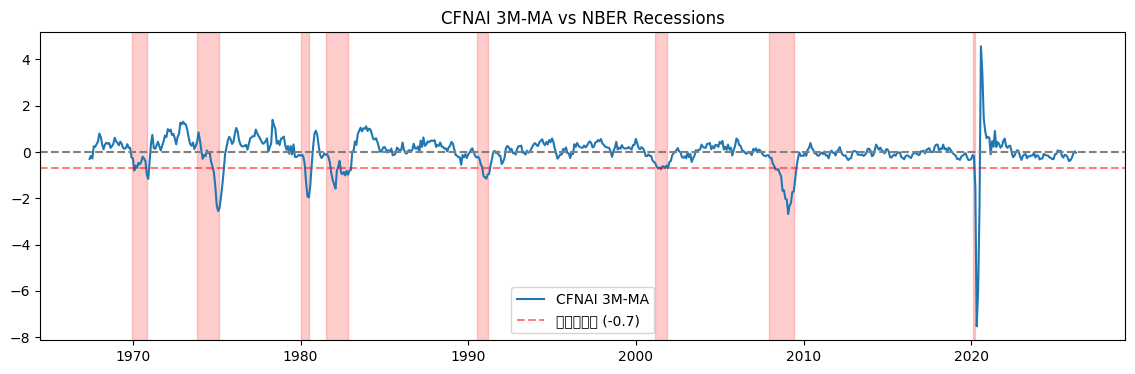

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cfnai_ma3.index, cfnai_ma3['cfnai_ma3'], label='CFNAI 3M-MA')
ax.axhline(0, color='gray', linestyle='--')
ax.axhline(-0.7, color='red', linestyle='--', alpha=0.5, label='衰退警戒线 (-0.7)')

# 标出官方 NBER 衰退区间
recessions = [
    ('1969-12', '1970-11'), ('1973-11', '1975-03'), ('1980-01', '1980-07'),
    ('1981-07', '1982-11'), ('1990-07', '1991-03'), ('2001-03', '2001-11'),
    ('2007-12', '2009-06'), ('2020-02', '2020-04'),
]
for start, end in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.2, color='red')

ax.legend()
ax.set_title('CFNAI 3M-MA vs NBER Recessions')
plt.show()

In [7]:
cfnai_ma3[['cfnai_ma3']].to_csv('/content/cfnai.csv')